In [1]:
import nibabel as nib 
import os 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns 
from skimage.metrics import mean_squared_error as mse
from scipy.spatial.distance import jensenshannon
import pandas as pd
from tqdm import tqdm
from math import log10
from scipy.stats import entropy
from scipy.interpolate import make_interp_spline
from scipy.stats import rankdata
from scipy.stats import wilcoxon, ranksums, mannwhitneyu

In [2]:
def kl_div(dist1, dist2):
    dist1_hist, dist1_bins = np.histogram(dist1, bins = 10, density = True)
    dist2_hist, dist2_bins = np.histogram(dist2, bins = 10, density = True)
    
    kl = entropy(dist1_hist, dist2_hist)
    return kl

In [3]:
kl_btob30f_scores = {}
kl_ctob30f_scores = {}
kl_dtob30f_scores = {}
mse_dtob_scores = {}
mse_dtoc_scores = {} 

b30f_b50f = pd.read_csv("/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/NLST_harmonization_validation_data/B30f_B50f/B30f_masked_emphysema/emph.csv")
b30f_b50f = b30f_b50f.sort_values(by='pid')
b = pd.read_csv("/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/NLST_harmonization_validation_data/B_D/B_emphysema/emph.csv")
b = b.sort_values(by='pid')
d_b = pd.read_csv("/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/NLST_harmonization_validation_data/B_D/D_emphysema/emph.csv")
d_b = d_b.sort_values(by='pid')
c = pd.read_csv("/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/NLST_harmonization_validation_data/C_D/C_emphysema/emph.csv")
c = c.sort_values(by='pid')
d_c = pd.read_csv("/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/NLST_harmonization_validation_data/C_D/D_emphysema/emph.csv")
d_c = d_c.sort_values(by='pid')

In [4]:
for i in tqdm(range(2,202,2)):
    btob30f = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage2/BtoB30f_emphysema/epoch_{i}/emph.csv")
    btob30f = btob30f.sort_values(by='pid')
    dtob30f = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage2/DtoB30f_emphysema/epoch_{i}/emph.csv")
    dtob30f = dtob30f.sort_values(by='pid')
    ctob30f = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage2/CtoB30f_emphysema/epoch_{i}/emph.csv")
    ctob30f = ctob30f.sort_values(by='pid')
    dtob = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage2/DtoB_emphysema/epoch_{i}/emph.csv")
    dtob = dtob.sort_values(by='pid')
    dtoc = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage2/DtoC_emphysema/epoch_{i}/emph.csv")
    dtoc = dtoc.sort_values(by='pid')

    mse_dtob_scores[i] = mse(dtob['emph_score'], b['emph_score'])
    mse_dtoc_scores[i] = mse(dtoc['emph_score'], c['emph_score'])
    kl_btob30f_scores[i] = kl_div(btob30f['emph_score'], b30f_b50f['emph_score'])
    kl_ctob30f_scores[i] = kl_div(ctob30f['emph_score'], b30f_b50f['emph_score'])
    kl_dtob30f_scores[i] = kl_div(dtob30f['emph_score'], b30f_b50f['emph_score'])

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:07<00:00, 14.34it/s]


In [5]:
mse_dtob_scores

{2: 11.887402625677044,
 4: 5.783109612493405,
 6: 8.24809138460397,
 8: 22.35977254302907,
 10: 2.6165705519774183,
 12: 1.3921352081081608,
 14: 19.13010520668491,
 16: 22.87797828835362,
 18: 6.2133904566722205,
 20: 7.6076839036959765,
 22: 11.407973782380404,
 24: 19.66740141078357,
 26: 9.543026913377028,
 28: 7.194251831548528,
 30: 8.08292061029102,
 32: 11.20574115893557,
 34: 1.1523423178394558,
 36: 11.012574202493722,
 38: 16.27553786449864,
 40: 10.176510609321744,
 42: 8.899442245065053,
 44: 1.4382245340870392,
 46: 14.297190200006161,
 48: 0.7422243125007482,
 50: 5.653008726258333,
 52: 0.9438960222014117,
 54: 16.880998296142526,
 56: 1.4706651584685013,
 58: 17.563800606548817,
 60: 1.2188013823663495,
 62: 1.1407405222808575,
 64: 19.549568605010194,
 66: 8.927516102091552,
 68: 16.551995890817842,
 70: 8.120895477937388,
 72: 30.473471625365992,
 74: 15.688768433426752,
 76: 14.268933061090026,
 78: 6.472175457894026,
 80: 7.211477076841071,
 82: 3.257614119162477,

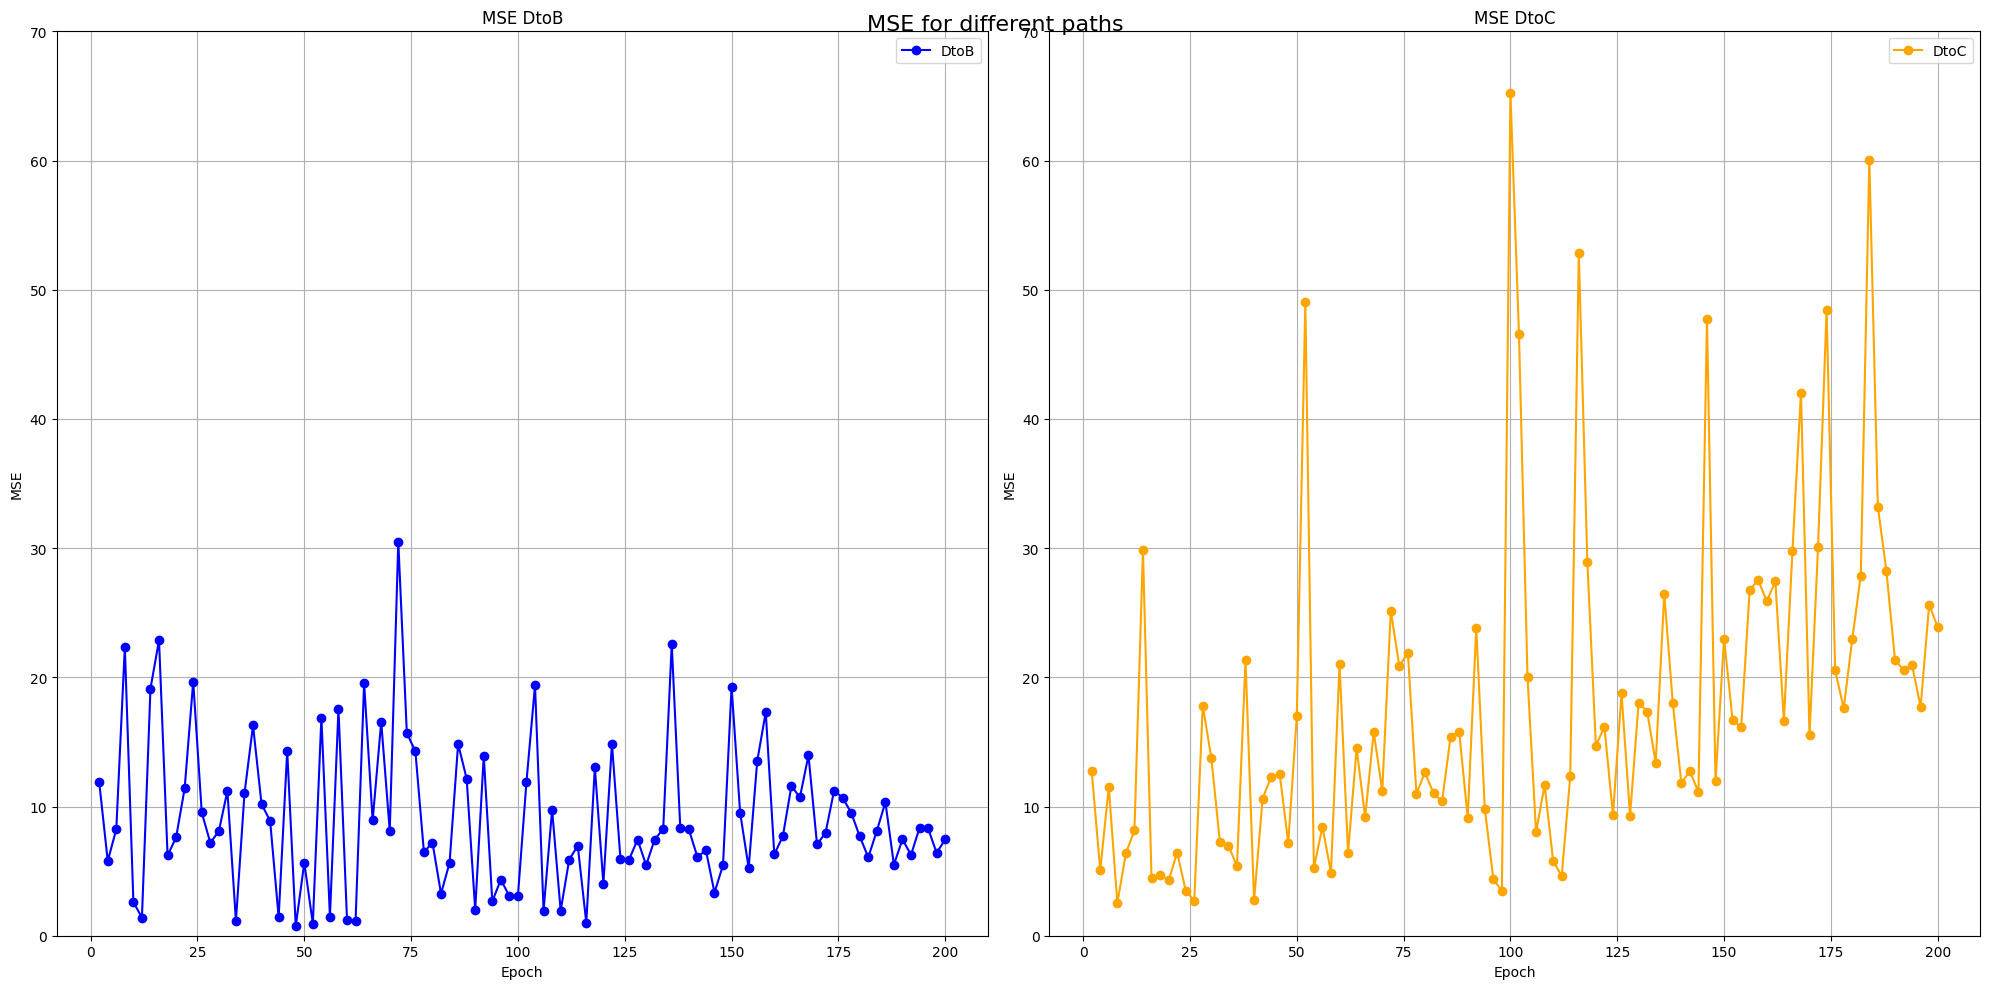

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].plot(list(mse_dtob_scores.keys()), list(mse_dtob_scores.values()), label='DtoB', marker = 'o', color='blue')
axes[0].set_title('MSE DtoB')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].set_ylim(0,70)
axes[0].legend()
axes[0].grid()

axes[1].plot(list(mse_dtoc_scores.keys()), list(mse_dtoc_scores.values()), label='DtoC', marker = 'o', color='orange')
axes[1].set_title('MSE DtoC')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE')
axes[1].set_ylim(0,70)
axes[1].legend()
axes[1].grid()
plt.tight_layout()
fig.suptitle('MSE for different paths', fontsize=16)
plt.show()

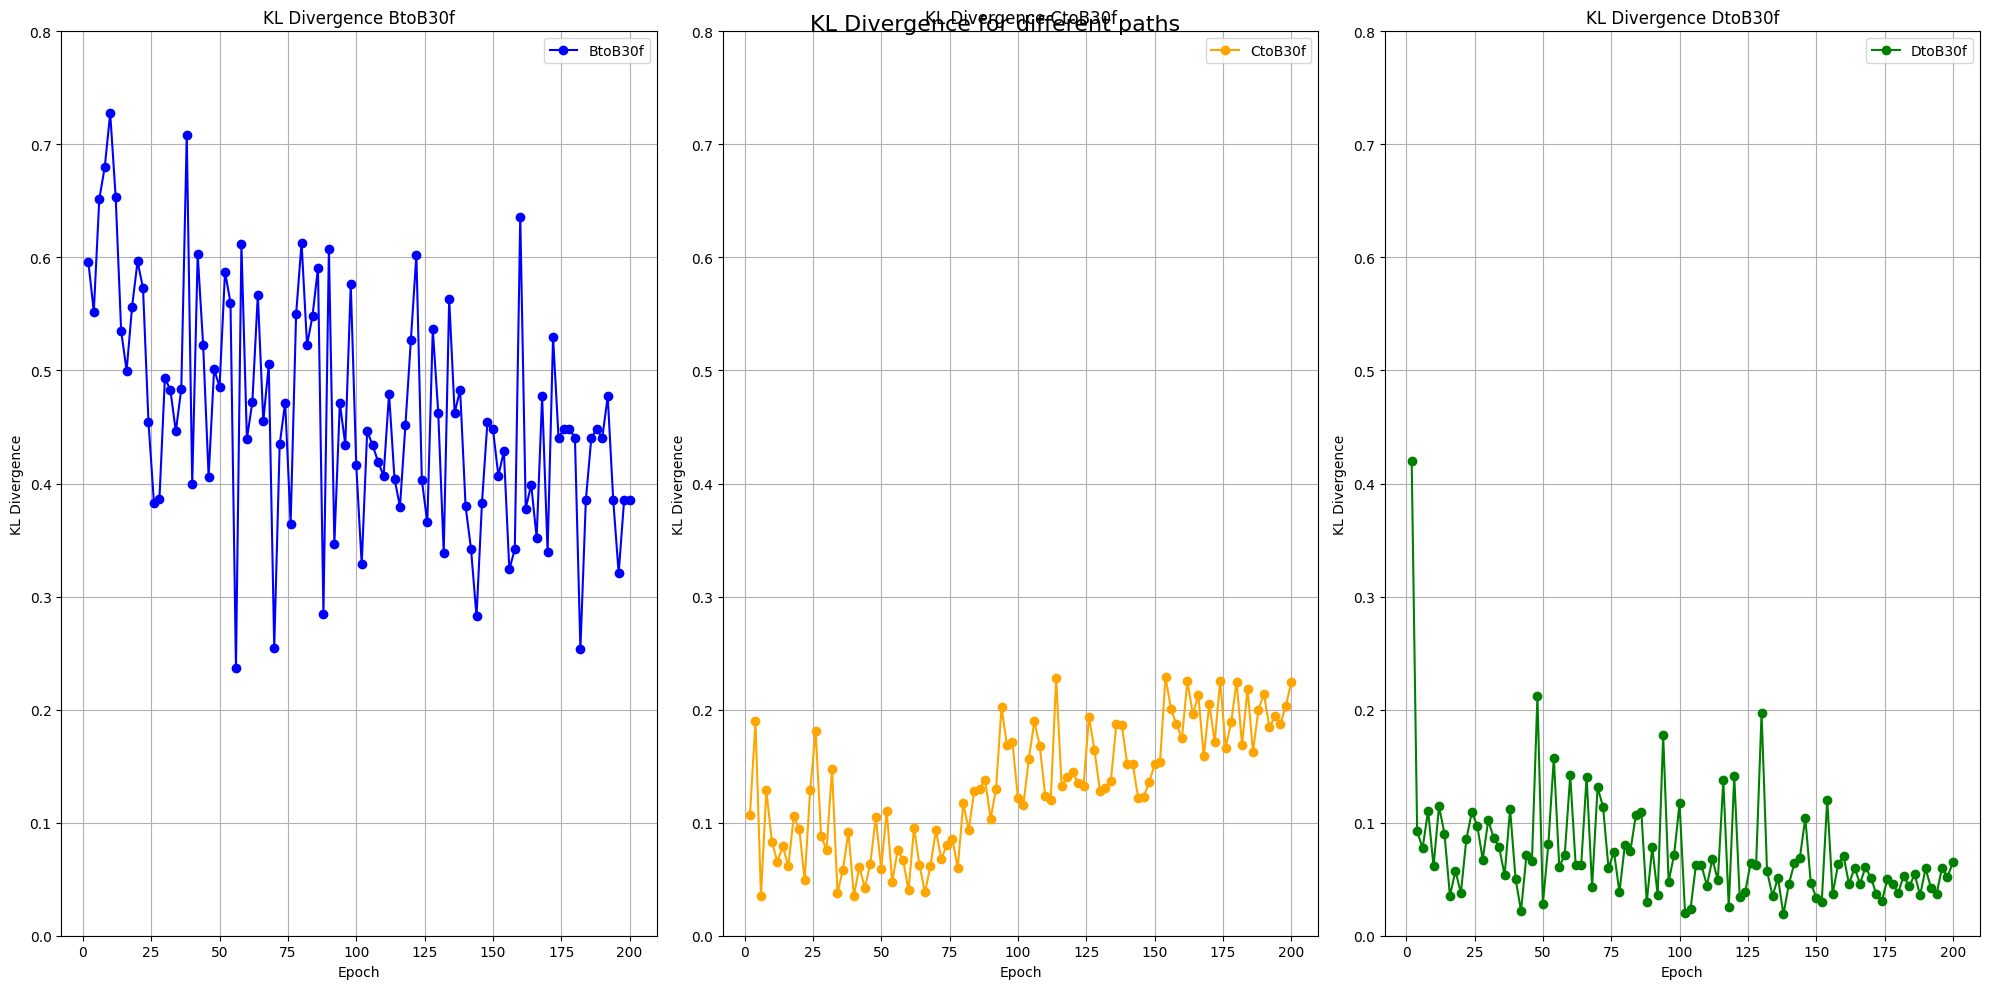

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
axes[0].plot(list(kl_btob30f_scores.keys()), list(kl_btob30f_scores.values()), label='BtoB30f', marker = 'o', color='blue')
axes[0].set_title('KL Divergence BtoB30f')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('KL Divergence')
axes[0].set_ylim(0, 0.8)
axes[0].legend()
axes[0].grid()

axes[1].plot(list(kl_ctob30f_scores.keys()), list(kl_ctob30f_scores.values()), label='CtoB30f', marker = 'o', color='orange')
axes[1].set_title('KL Divergence CtoB30f')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('KL Divergence')
axes[1].set_ylim(0, 0.8)
axes[1].legend()
axes[1].grid()

axes[2].plot(list(kl_dtob30f_scores.keys()), list(kl_dtob30f_scores.values()), label='DtoB30f', marker = 'o', color='green')
axes[2].set_title('KL Divergence DtoB30f')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL Divergence')
axes[2].set_ylim(0, 0.8)
axes[2].legend()
axes[2].grid()

plt.tight_layout()
fig.suptitle('KL Divergence for different paths', fontsize=16)
plt.show()

In [8]:
mse_dtob_scores_ranks = rankdata(list(mse_dtob_scores.values()))
mse_dtoc_scores_ranks = rankdata(list(mse_dtoc_scores.values()))
kl_btob30f_scores_ranks = rankdata(list(kl_btob30f_scores.values()))
kl_ctob30f_scores_ranks = rankdata(list(kl_ctob30f_scores.values()))
kl_dtob30f_scores_ranks = rankdata(list(kl_dtob30f_scores.values()))

mse_dtob_rank = {list(mse_dtob_scores.keys())[i]: mse_dtob_scores_ranks[i] for i in range(len(mse_dtob_scores_ranks))}
mse_dtoc_rank = {list(mse_dtoc_scores.keys())[i]: mse_dtoc_scores_ranks[i] for i in range(len(mse_dtoc_scores_ranks))}
kl_btob30f_rank = {list(kl_btob30f_scores.keys())[i]: kl_btob30f_scores_ranks[i] for i in range(len(kl_btob30f_scores_ranks))}
kl_ctob30f_rank = {list(kl_ctob30f_scores.keys())[i]: kl_ctob30f_scores_ranks[i] for i in range(len(kl_ctob30f_scores_ranks))}
kl_dtob30f_rank = {list(kl_dtob30f_scores.keys())[i]: kl_dtob30f_scores_ranks[i] for i in range(len(kl_dtob30f_scores_ranks))}

mse_dtob_rank = dict(sorted(mse_dtob_rank.items()))
mse_dtoc_rank = dict(sorted(mse_dtoc_rank.items()))
kl_btob30f_rank = dict(sorted(kl_btob30f_rank.items()))
kl_ctob30f_rank = dict(sorted(kl_ctob30f_rank.items()))
kl_dtob30f_rank = dict(sorted(kl_dtob30f_rank.items()))

In [14]:
overall_stage_two_rank = {}
for key in mse_dtob_rank.keys():
    overall_stage_two_rank[key] = (0.5*mse_dtob_rank[key] + 0.5*mse_dtoc_rank[key] + 0.5*kl_btob30f_rank[key] + 
                                   0.5*kl_ctob30f_rank[key] + 0.5*kl_dtob30f_rank[key])
    # overall_stage_two_rank[key] = (0.5*kl_btob30f_rank[key] + 
    #                                0.5*kl_ctob30f_rank[key] + 0.5*kl_dtob30f_rank[key])

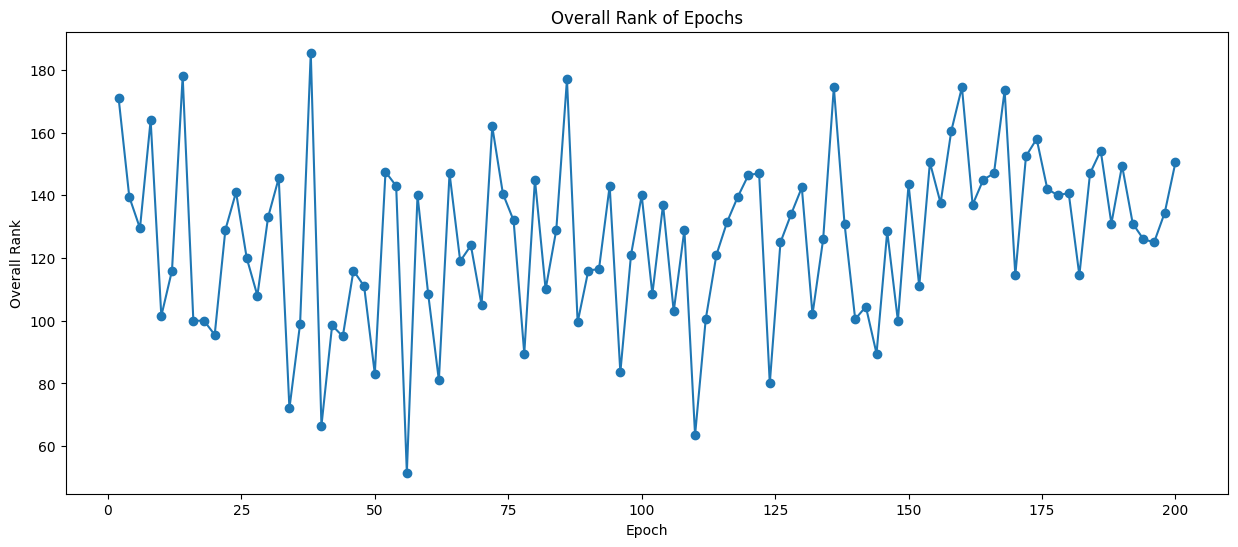

In [15]:
plt.figure(figsize=(15, 6))
plt.plot(list(overall_stage_two_rank.keys()), list(overall_stage_two_rank.values()), marker='o')
plt.xlabel("Epoch")
plt.ylabel("Overall Rank")
plt.title("Overall Rank of Epochs")
plt.show()

In [16]:
best_epoch = min(overall_stage_two_rank, key=overall_stage_two_rank.get)
print(f"The best epoch is: {best_epoch} with rank {overall_stage_two_rank[best_epoch]}")

The best epoch is: 56 with rank 51.5


In [22]:
#Epoch 56 results
btob30f_best = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage2/BtoB30f_emphysema/epoch_56/emph.csv")
btob30f_best = btob30f_best.sort_values(by='pid')
dtob30f_best = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage2/DtoB30f_emphysema/epoch_56/emph.csv")
dtob30f_best = dtob30f_best.sort_values(by='pid')
ctob30f_best = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage2/CtoB30f_emphysema/epoch_56/emph.csv")
ctob30f_best = ctob30f_best.sort_values(by='pid')
dtob_best = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage2/DtoB_emphysema/epoch_56/emph.csv")
dtob_best = dtob_best.sort_values(by='pid')
dtoc_best = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage2/DtoC_emphysema/epoch_56/emph.csv")
dtoc_best = dtoc_best.sort_values(by='pid')

In [ ]:
# #Epoch 102 results
# btob30f_best = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage2/BtoB30f_emphysema/epoch_102/emph.csv")
# btob30f_best = btob30f_best.sort_values(by='pid')
# dtob30f_best = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage2/DtoB30f_emphysema/epoch_102/emph.csv")
# dtob30f_best = dtob30f_best.sort_values(by='pid')
# ctob30f_best = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage2/CtoB30f_emphysema/epoch_102/emph.csv")
# ctob30f_best = ctob30f_best.sort_values(by='pid')
# dtob_best = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage2/DtoB_emphysema/epoch_102/emph.csv")
# dtob_best = dtob_best.sort_values(by='pid')
# dtoc_best = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage2/DtoC_emphysema/epoch_102/emph.csv")
# dtoc_best = dtoc_best.sort_values(by='pid')

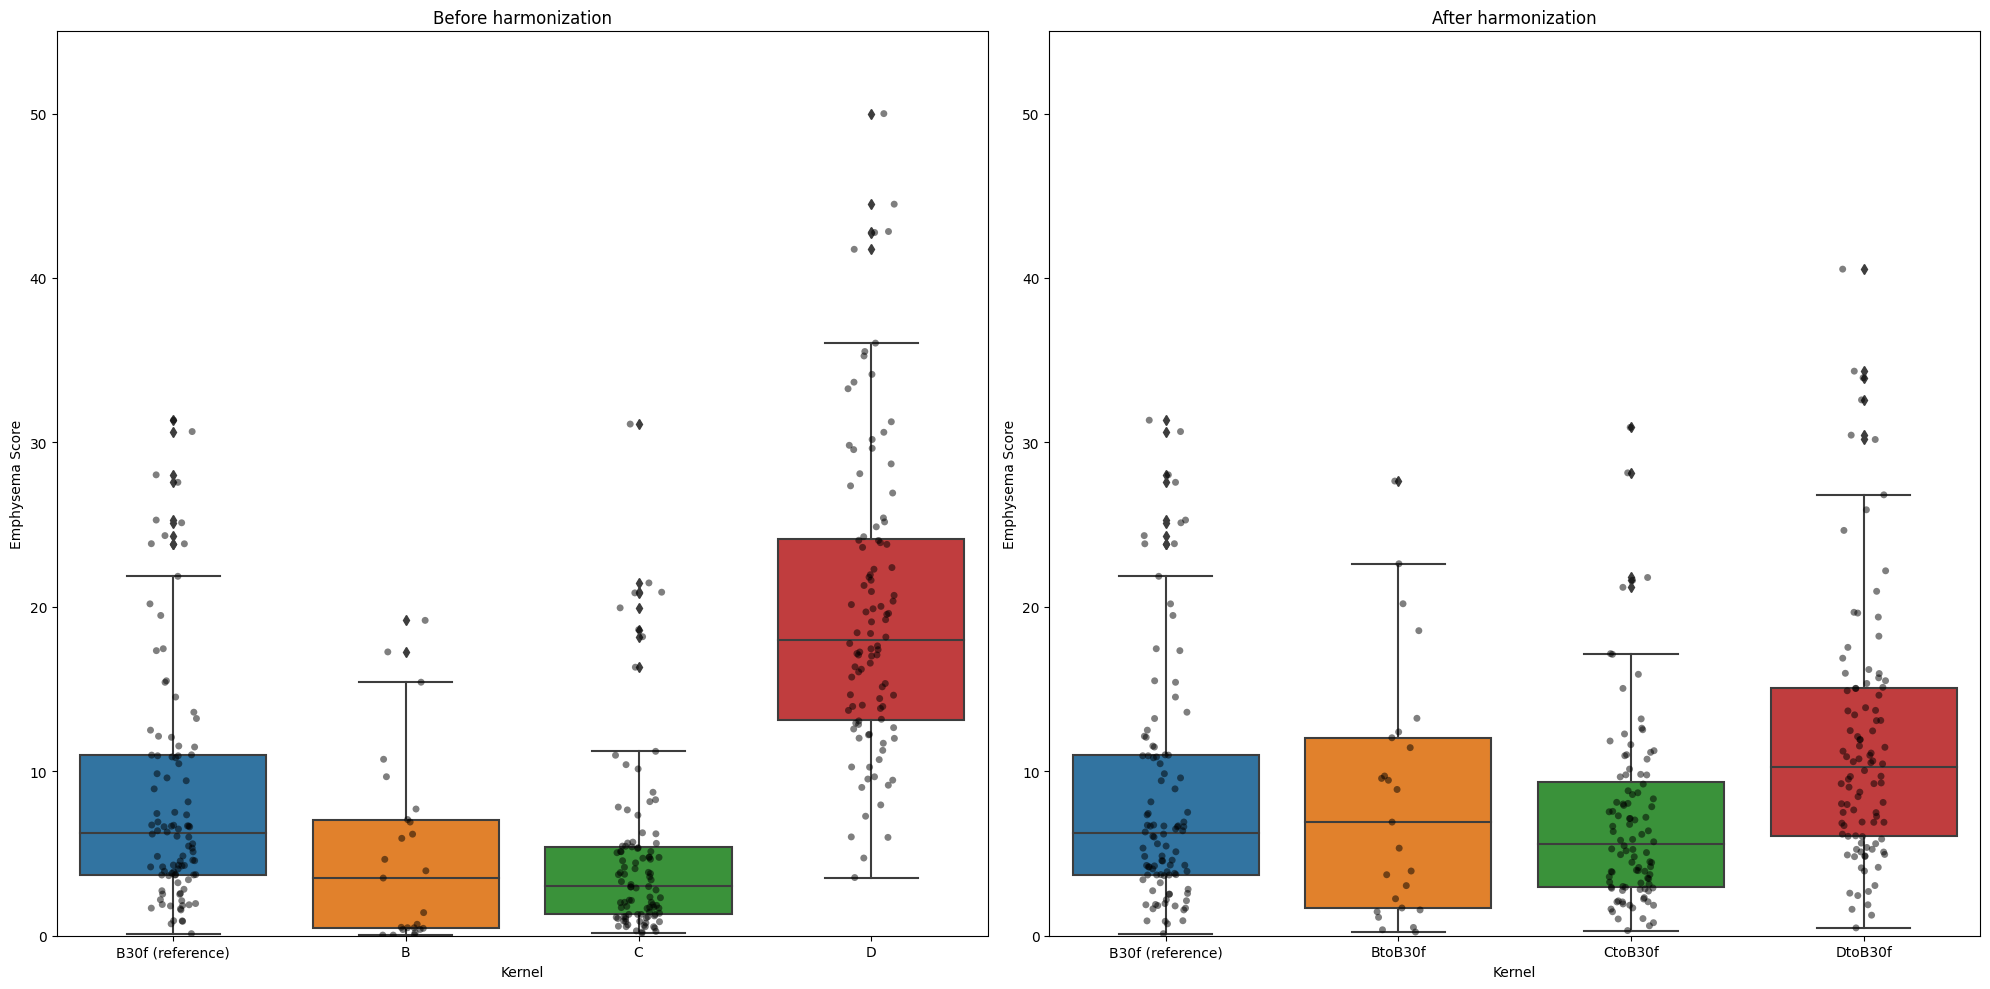

In [23]:
fig, axes = plt.subplots(1,2 , figsize=(20, 10))
sns.boxplot(data=[b30f_b50f['emph_score'], b['emph_score'], c['emph_score'], d_c['emph_score']], ax=axes[0])
sns.stripplot(data=[b30f_b50f['emph_score'], b['emph_score'], c['emph_score'], d_c['emph_score']], ax=axes[0], color='black', alpha=0.5)
axes[0].set_xticks([0, 1, 2, 3])
axes[0].set_xticklabels(['B30f (reference)', 'B', 'C', 'D'])
axes[0].set_title('Before harmonization')
axes[0].set_ylabel('Emphysema Score')
axes[0].set_ylim(0, 55)
axes[0].set_xlabel('Kernel')

sns.boxplot(data=[b30f_b50f['emph_score'], btob30f_best['emph_score'], ctob30f_best['emph_score'], dtob30f_best['emph_score']], ax=axes[1])
sns.stripplot(data=[b30f_b50f['emph_score'], btob30f_best['emph_score'], ctob30f_best['emph_score'], dtob30f_best['emph_score']], ax=axes[1], color='black', alpha=0.5)
axes[1].set_xticks([0, 1, 2, 3])
axes[1].set_xticklabels(['B30f (reference)', 'BtoB30f', 'CtoB30f', 'DtoB30f'])
axes[1].set_title('After harmonization')
axes[1].set_ylabel('Emphysema Score')
axes[1].set_ylim(0, 55)
axes[1].set_xlabel('Kernel')

plt.tight_layout()
plt.show()

In [15]:
#Paired data emphysema scores: Bland Altman analysis
def bland_altman_conversion_without_mean(hard, soft, converted,x_plot_range, y_plot_range):
    sd_limit = 1.96
    # annotation_font_size = 15
    annotation_font_size = 16

    fig, ax = plt.subplots(figsize=(10, 5), facecolor = "w")

    scatter_kwds = {'s': 20}
    mean_line_kwds = {}
    limit_lines_kwds = {}
    for kwds in [mean_line_kwds, limit_lines_kwds]:
        # if 'color' not in kwds:
        #     kwds['color'] = 'gray'
        if 'linewidth' not in kwds:
            kwds['linewidth'] = 2


    diff_list_before = np.array(hard) - np.array(soft)

    mean_diff_before = np.mean(diff_list_before)
    std_diff_before = np.std(diff_list_before)

    diff_list_after = np.array(converted) - np.array(soft)

    mean_diff_after = np.mean(diff_list_after)
    std_diff_after = np.std(diff_list_after)
    
    plt.title("Agreement before and after kernel harmonization", fontsize = 18)

    ax.scatter(np.array(soft),diff_list_before, color='blue',s=10,alpha=0.5)
    ax.scatter(np.array(soft),diff_list_after, color='red',s=10,alpha=0.3)

    ax.set_ylim(y_plot_range[0], y_plot_range[1])
    ax.set_xlim(x_plot_range[0], x_plot_range[1])

    limit_of_agreement_before = sd_limit * std_diff_before
    lower_before = mean_diff_before - limit_of_agreement_before
    upper_before = mean_diff_before + limit_of_agreement_before 

    limit_of_agreement_after = sd_limit * std_diff_after
    lower_after = mean_diff_after - limit_of_agreement_after
    upper_after = mean_diff_after + limit_of_agreement_after 

    
    # for j, lim in enumerate([lower, upper]):
    ax.axhline(lower_before, linestyle='dotted', label=f'Before Conversion: -1.96 SD = {np.round(lower_before, 2)}',
               color='blue', alpha=0.5, **limit_lines_kwds)
    ax.axhline(upper_before, linestyle='dashed', label=f'Before Conversion: +1.96 SD = {np.round(upper_before, 2)}',
               color='blue', alpha=0.5, **limit_lines_kwds)
    ax.axhline(mean_diff_before, linestyle='solid', color='blue',
               label=f'Before Conversion: Mean Difference = {np.round(mean_diff_before, 2)}', alpha=0.5, **mean_line_kwds)
    

    ax.axhline(lower_after, linestyle='dotted', label=f'After Conversion: -1.96 SD = {np.round(lower_after, 2)}',
               color='red', alpha=0.5, **limit_lines_kwds)
    ax.axhline(upper_after, linestyle='dashed', label=f'After Conversion: +1.96 SD = {np.round(upper_after, 2)}',
               color='red', alpha=0.5, **limit_lines_kwds)
    ax.axhline(mean_diff_after, linestyle='solid', color='red',
               label=f'After Conversion: Mean Difference = {np.round(mean_diff_after, 2)}', alpha=0.5, **mean_line_kwds)

    ax.set_ylabel("Difference between measures of emphysema", fontsize=annotation_font_size)
    ax.set_xlabel("Ground truth emphysema measurement", fontsize=annotation_font_size)
    ax.tick_params(axis='x', labelsize=annotation_font_size)
    ax.tick_params(axis='y', labelsize=annotation_font_size)

    ax.legend(loc='best', fontsize=int(round(0.9 * annotation_font_size)))
    plt.gcf().set_dpi(300)
    # plt.savefig("bland_altman_emphysema.png", dpi = 300)
    plt.show() 

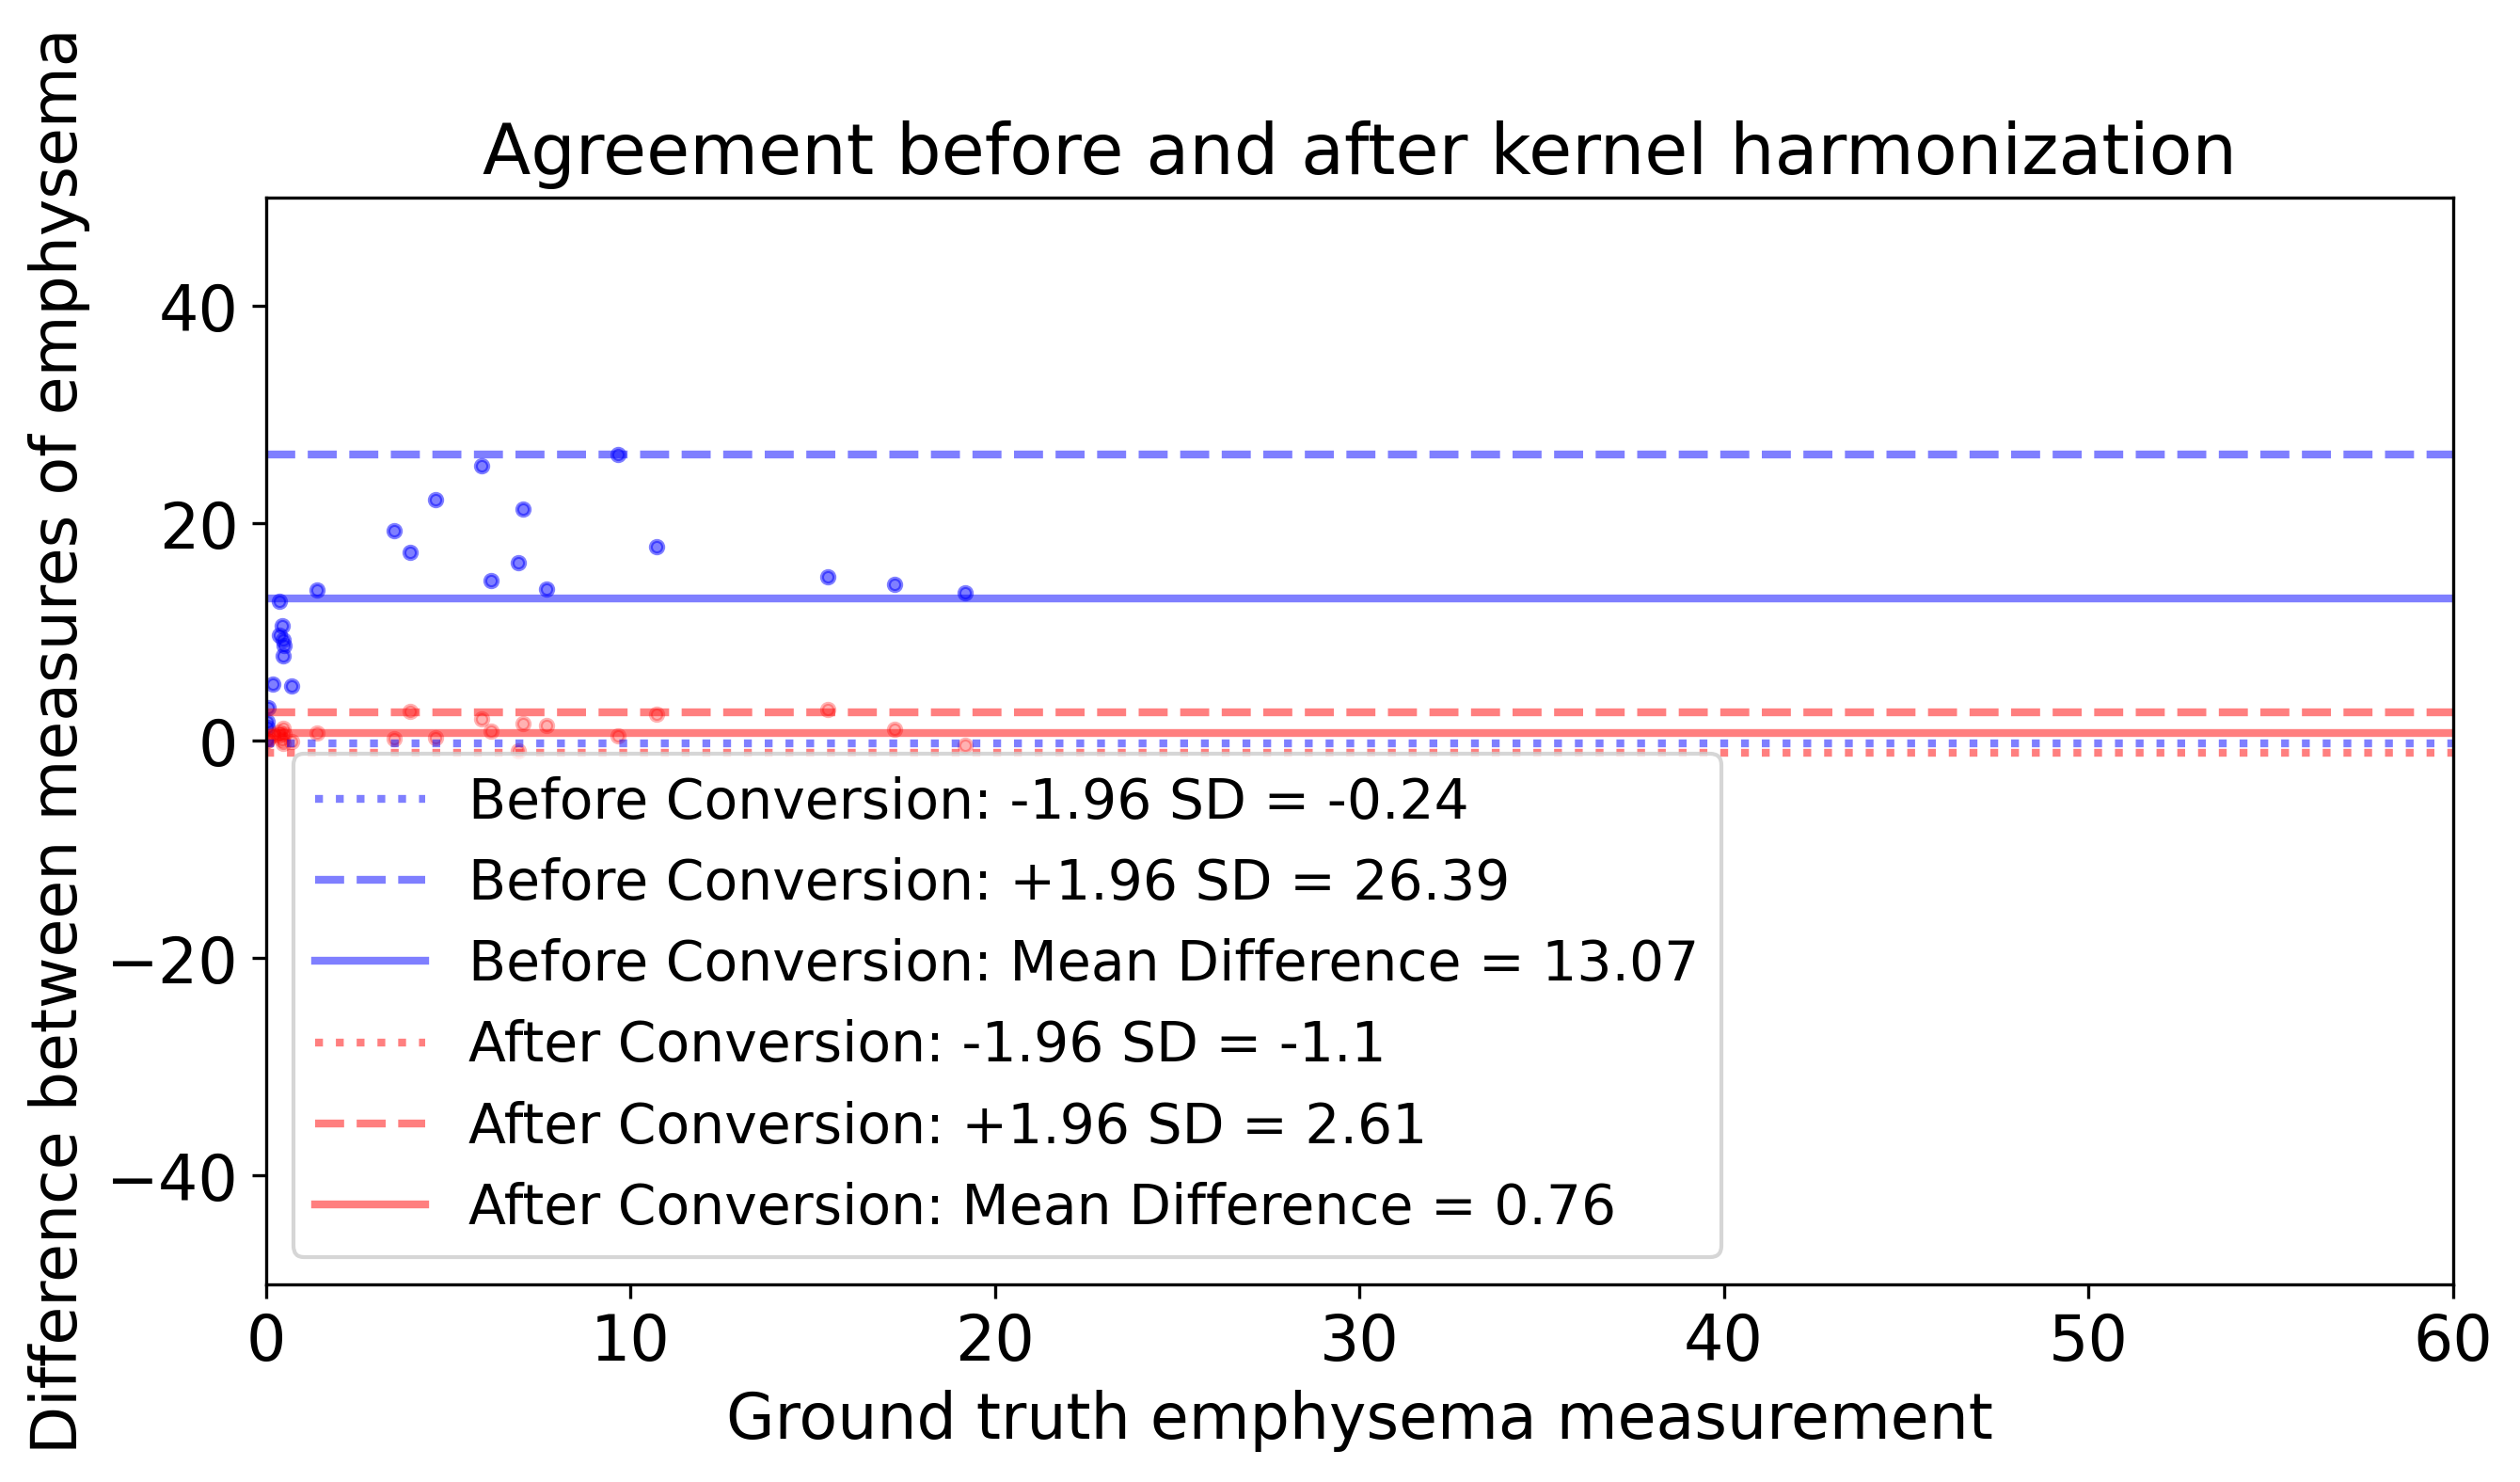

In [16]:
bland_altman_conversion_without_mean(d_b['emph_score'], b['emph_score'], dtob_best['emph_score'],
                                      x_plot_range = [0, 60], y_plot_range = [-50, 50])

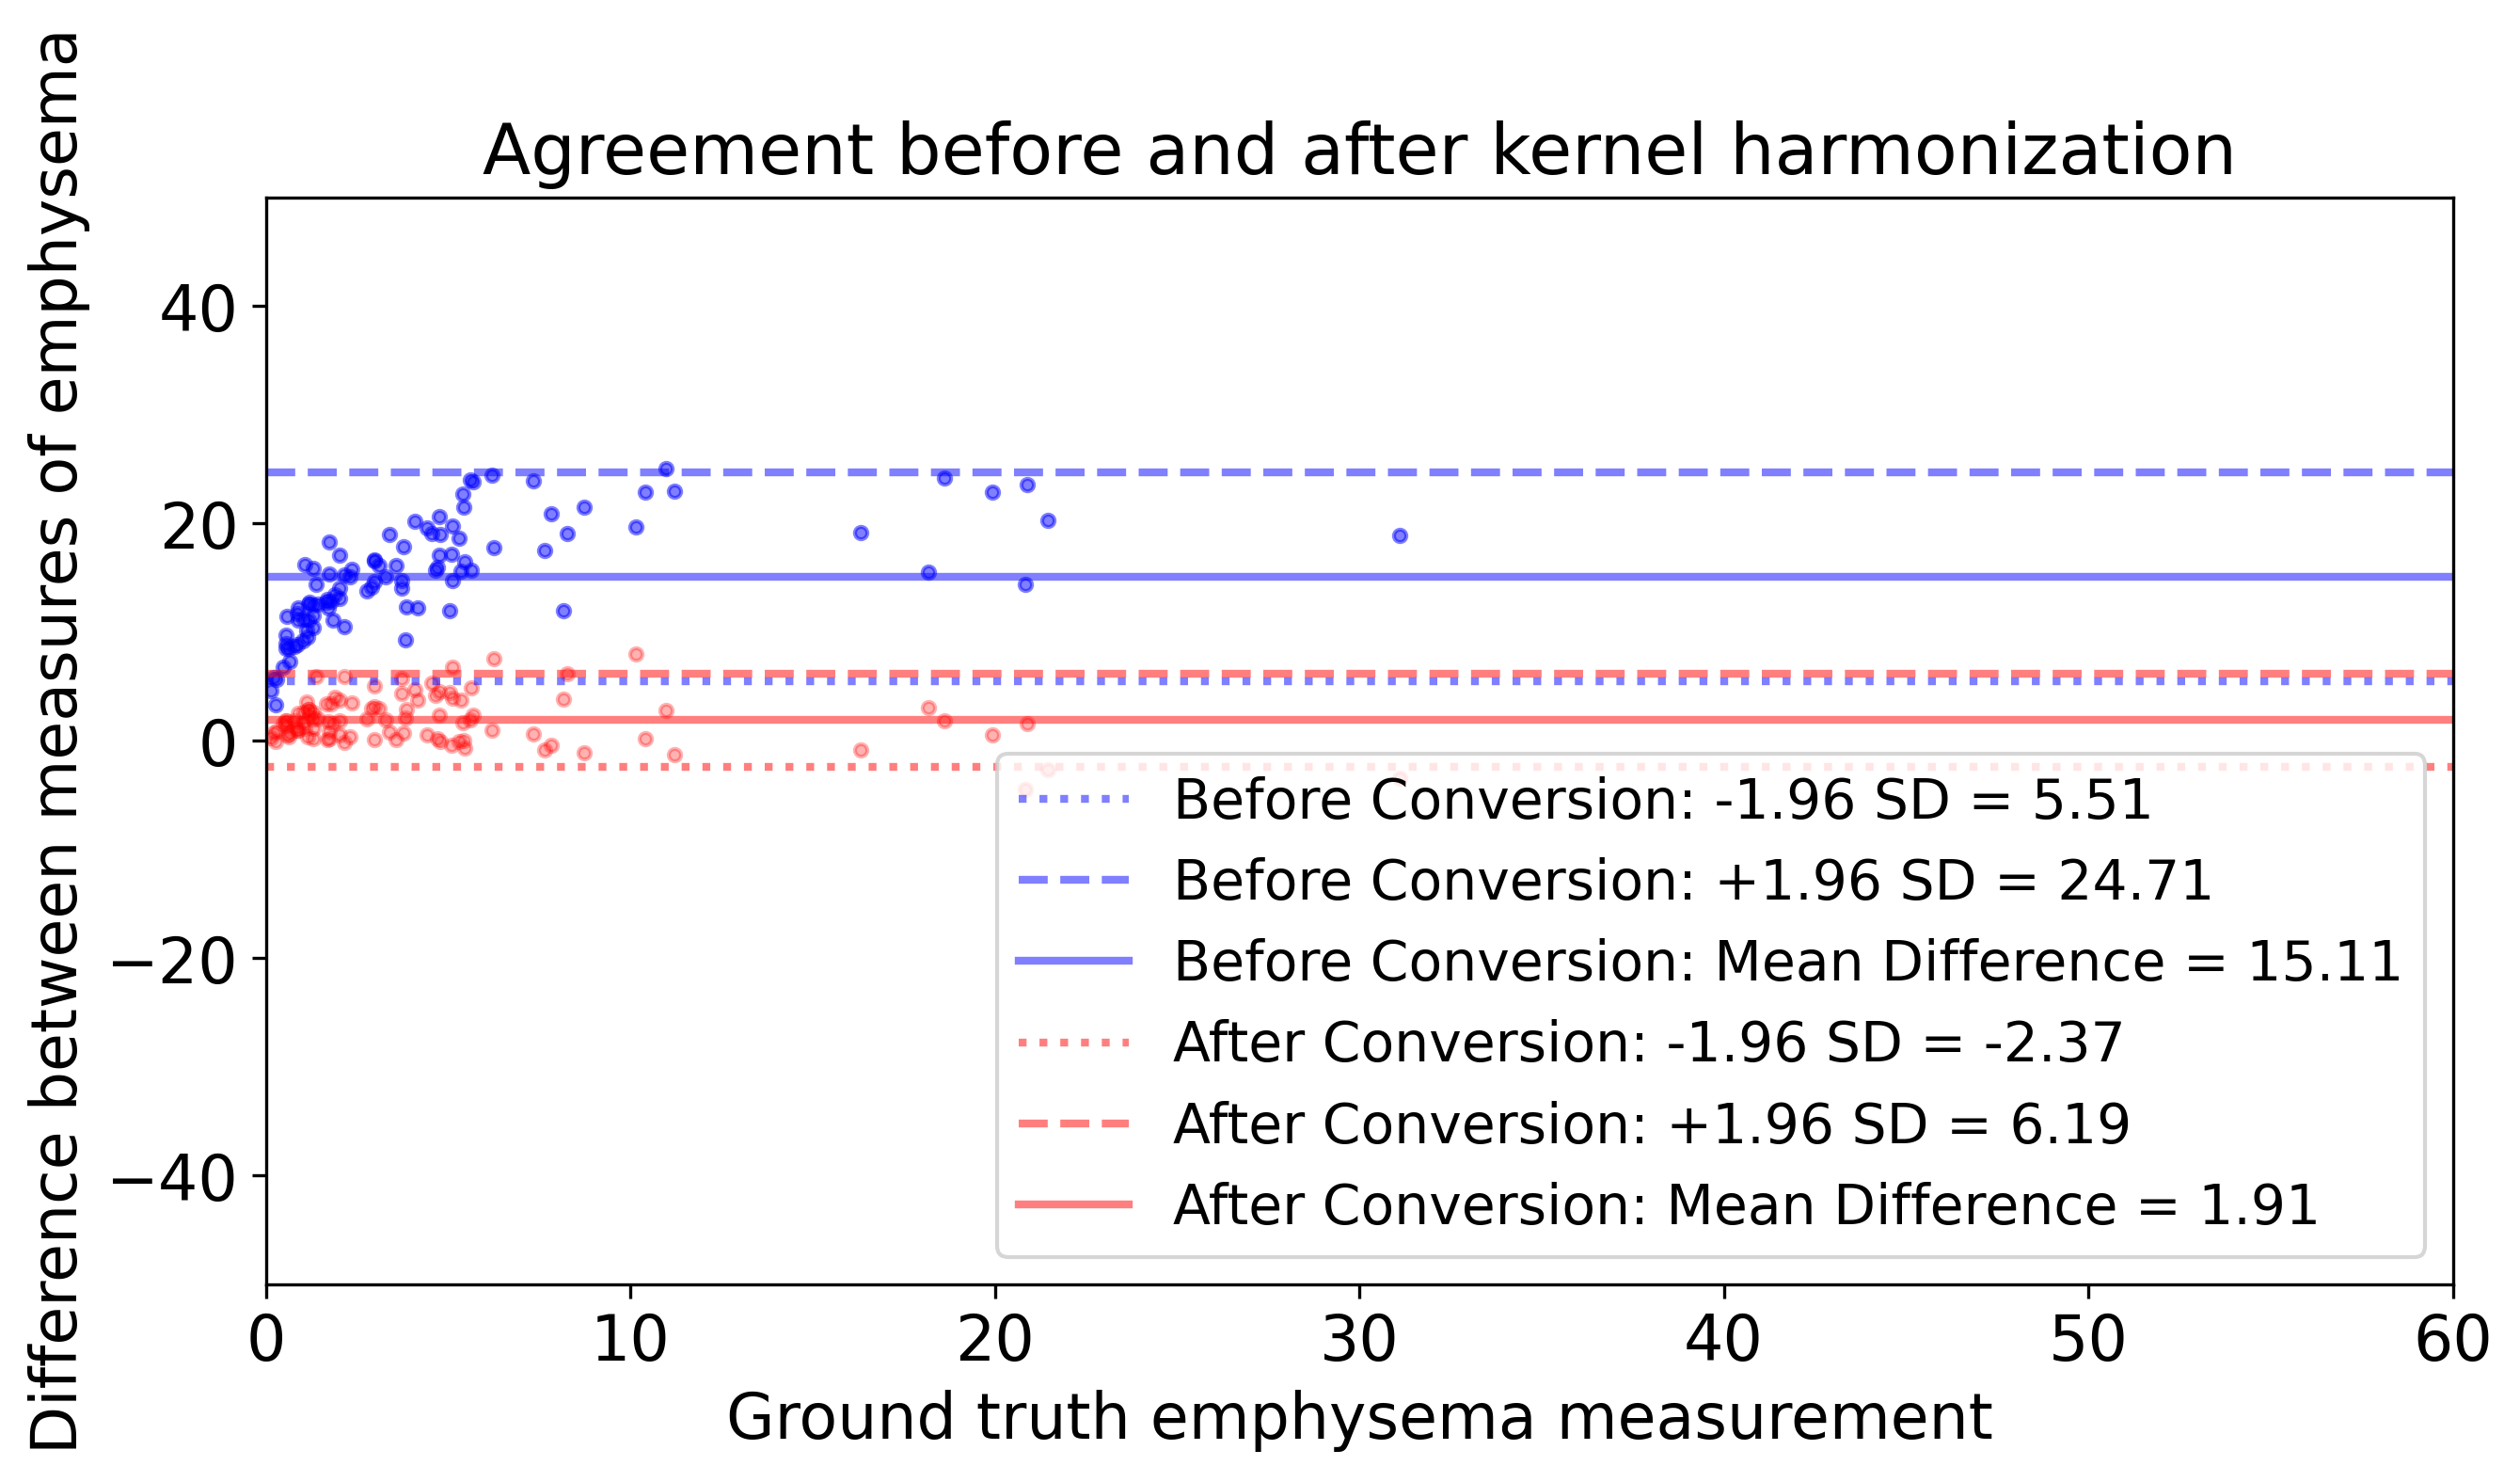

In [17]:
bland_altman_conversion_without_mean(d_c['emph_score'], c['emph_score'], dtoc_best['emph_score'],
                                      x_plot_range = [0, 60], y_plot_range = [-50, 50])